# SBDR - Data Loading & Exploration

This notebook handles initial data loading, inspection, and basic exploration
for the Sentimental-Behavioral Debt Recovery project.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print('Setup complete.')

Setup complete.


In [4]:
pwd

'/Users/rajdeeproy/UMBC/ObsidianVaults/Interview Prep/Projects/SBDR/notebooks'

In [7]:
!pip install xlrd

## 1. Data Loading & Metadata

### Dataset: UCI Credit Card Default
**Source:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/default+of+credit+card+clients)  
**Dimensions:** 30,000 rows × 25 columns  
**Role:** Primary anchor dataset for BiLSTM architecture and target merging.

---

### Variable Dictionary

#### Target Variable
* **default payment next month:** Binary response (Yes = 1, No = 0)

#### Explanatory Variables (Features)
| ID | Feature | Description | Coding / Scale |
| :--- | :--- | :--- | :--- |
| **X1** | **LIMIT_BAL** | Amount of given credit (NT dollar) | Includes individual & family credit |
| **X2** | **SEX** | Gender | 1 = Male; 2 = Female |
| **X3** | **EDUCATION** | Education Level | 1 = Grad School; 2 = University; 3 = High School; 4 = Others |
| **X4** | **MARRIAGE** | Marital Status | 1 = Married; 2 = Single; 3 = Others |
| **X5** | **AGE** | Age | Years |

#### Temporal Features (April – September 2005)

| Feature Group | Column Names | Description |
| :--- | :--- | :--- |
| **Repayment Status** | `PAY_0` to `PAY_6` | **X6 - X11:** -1 = pay duly; 1 = delay 1 mo; ... 9 = delay 9+ mos |
| **Bill Statement** | `BILL_AMT1` to `BILL_AMT6` | **X12 - X17:** Amount of bill statement (NT dollar) |
| **Previous Payment** | `PAY_AMT1` to `PAY_AMT6` | **X18 - X23:** Amount of previous payment (NT dollar) |

> **Note on Temporal Ordering:** `PAY_0`, `BILL_AMT1`, and `PAY_AMT1` represent the most recent month (September), while `PAY_6`, `BILL_AMT6`, and `PAY_AMT6` represent the oldest month (April).l, 2005.

In [28]:
df = pd.read_excel("../data/raw/default of credit card clients.xls", header=1)

## Basic Exploration

In [27]:
df.head(5)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [9]:
df.shape

(30000, 25)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [11]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [14]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')

In [15]:
print(f"\n=== Null Values ===")
print(df.isnull().sum().sum(), "total nulls")


=== Null Values ===
0 total nulls


## Target Variable: `default payment next month`
This is what we're ultimately predicting. Let's see how balanced the classes are — imbalanced data will affect our model training later.

In [17]:
target = df['default payment next month'].value_counts()
print(f"No Default (0): {target[0]} ({target[0]/len(df)*100:.1f}%)")
print(f"Default (1):    {target[1]} ({target[1]/len(df)*100:.1f}%)")

No Default (0): 23364 (77.9%)
Default (1):    6636 (22.1%)


/var/folders/sq/5sx7g2w17zjc98wp4_pf62fw0000gn/T/ipykernel_52668/3021922237.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Default', 'Default'])


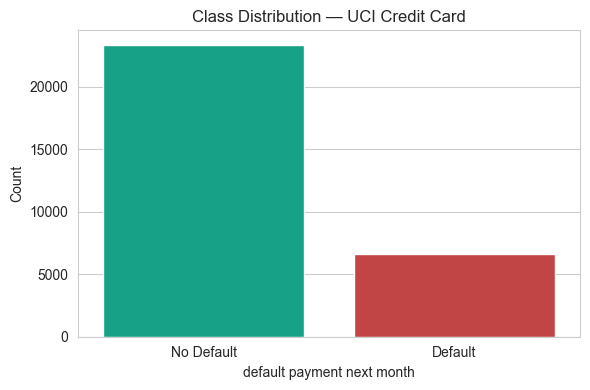

[Text(0, 0, 'No Default'), Text(1, 0, 'Default')]

In [22]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x='default payment next month', data=df, hue='default payment next month', palette=['#00b894', '#d63031'], legend=False, ax=ax)
ax.set_xticklabels(['No Default', 'Default'])
ax.set_title('Class Distribution — UCI Credit Card')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()
# for the tick labels warning
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Default', 'Default'])

## Payment History: PAY_0 to PAY_6
These 6 columns are the heartbeat of our project — they feed the BiLSTM. Each value represents how late a customer was that month:
- `-1` = paid on time
- `0` = minimum payment
- `1` = 1 month late
- `2+` = progressively worse

In [23]:
# Payment status distribution across 6 months
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
#Creating a list as we can easily apply the operations on all 6 cols simultaneously.

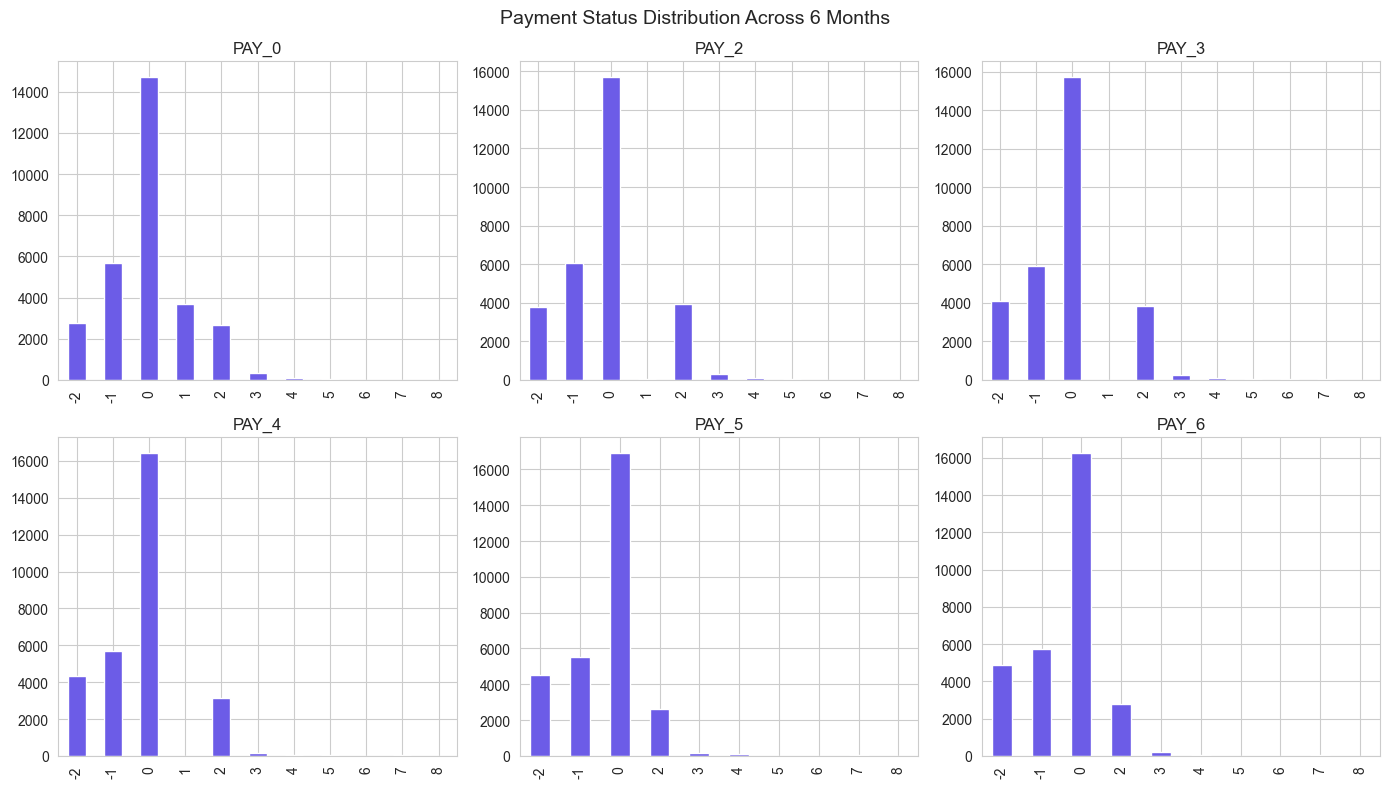

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(pay_cols):
    df[col].value_counts().sort_index().plot(kind='bar', ax=axes[i], color='#6c5ce7')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('Payment Status Distribution Across 6 Months', fontsize=14)
plt.tight_layout()
plt.show()

In [25]:
# How many customers got progressively worse?
print("=== Mean payment status per month ===")
print(df[pay_cols].mean().round(3))

=== Mean payment status per month ===
PAY_0   -0.017
PAY_2   -0.134
PAY_3   -0.166
PAY_4   -0.221
PAY_5   -0.266
PAY_6   -0.291
dtype: float64


The columns go PAY_6 (oldest) → PAY_0 (most recent). 

The average is climbing toward zero over time. That means as a group, customers are drifting from on-time (-1) toward late payments (0 and above).

## Bill Amounts & Payment Amounts (6-Month Trend)
`BILL_AMT1–6` = how much the customer owed each month

`PAY_AMT1–6` = how much they actually paid

The gap between these two tells us if someone is barely keeping up or falling behind.

In [29]:
bill_cols = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
pay_amt_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']

# Average bill vs average payment over 6 months
avg_bill = df[bill_cols].mean()
avg_pay = df[pay_amt_cols].mean()


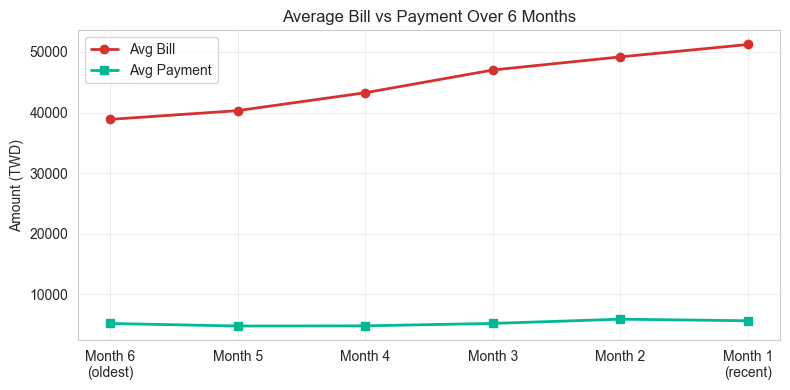

In [30]:
fig, ax = plt.subplots(figsize=(8, 4))
months = ['Month 6\n(oldest)', 'Month 5', 'Month 4', 'Month 3', 'Month 2', 'Month 1\n(recent)']
ax.plot(months, avg_bill.values[::-1], marker='o', label='Avg Bill', color='#d63031', linewidth=2)
ax.plot(months, avg_pay.values[::-1], marker='s', label='Avg Payment', color='#00b894', linewidth=2)
ax.set_title('Average Bill vs Payment Over 6 Months')
ax.set_ylabel('Amount (TWD)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
# The gap — are people paying less than they owe?
print("Avg Payment as % of Bill")
for i in range(6):
    ratio = df[pay_amt_cols[i]].mean() / df[bill_cols[i]].mean() * 100
    print(f"Month {6-i}: {ratio:.1f}%")

Avg Payment as % of Bill
Month 6: 11.1%
Month 5: 12.0%
Month 4: 11.1%
Month 3: 11.2%
Month 2: 11.9%
Month 1: 13.4%
